# 从零实现 k 近邻回归：国家生活满意度预测

本 notebook 将三份课程材料合并为一条完整、去重的分析流程。目标是使用**人均 GDP**和**就业率**预测国家的生活满意度，并通过留一交叉验证选择近邻数量 `k`。

## 项目亮点

- 仅使用 NumPy 和 pandas，从零实现 k-NN 回归。
- 展示单特征与多特征距离的区别。
- 在每个验证折中只使用训练数据计算标准化参数，避免数据泄漏。
- 使用留一交叉验证选择 `k`，并与均值及线性回归基线比较。
- 将日本完整保留为最终测试样本。

> 教学结构参考 `tomonari-masada/course2026-sml` 中的 k 近邻课程 notebook；本文件重新组织了结构、代码、注释与分析。数据来源和再发布许可仍需进一步确认。

## 1. 环境与数据准备

数据包含 2011—2024 年的国家生活满意度、人均 GDP 和就业率。本分析只使用 2024 年数据；日本作为最终测试样本，其余国家用于训练和交叉验证。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_rows", 50)
pd.set_option("display.precision", 4)

# 同时兼容从仓库根目录和 notebooks/ 目录启动 Jupyter。
data_candidates = [
    Path("data/life_satisfaction_2010_2024.csv"),
    Path("../data/life_satisfaction_2010_2024.csv"),
]
data_path = next((path for path in data_candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("未找到 data/life_satisfaction_2010_2024.csv")

raw = pd.read_csv(data_path)
data_2024 = raw.loc[raw["Year"] == 2024].set_index("Country")

# 日本只用于最终测试，调参阶段不读取其目标值。
train = data_2024.drop(index="Japan")
test = data_2024.loc[["Japan"]]

FEATURES = ["GDP per capita", "Employment Rate (%)"]
TARGET = "Life Satisfaction"
X = train[FEATURES].astype(float)
y = train[TARGET].astype(float)

print(f"原始数据：{len(raw)} 行，年份范围 {raw['Year'].min()}—{raw['Year'].max()}")
print(f"2024 年训练国家：{len(train)}；测试国家：{test.index[0]}")

原始数据：555 行，年份范围 2011—2024
2024 年训练国家：41；测试国家：Japan


## 2. 探索性分析

下图分别观察人均 GDP、就业率与生活满意度之间的关系。人均 GDP 呈现更明显的正相关趋势；就业率与生活满意度的关系相对较弱。

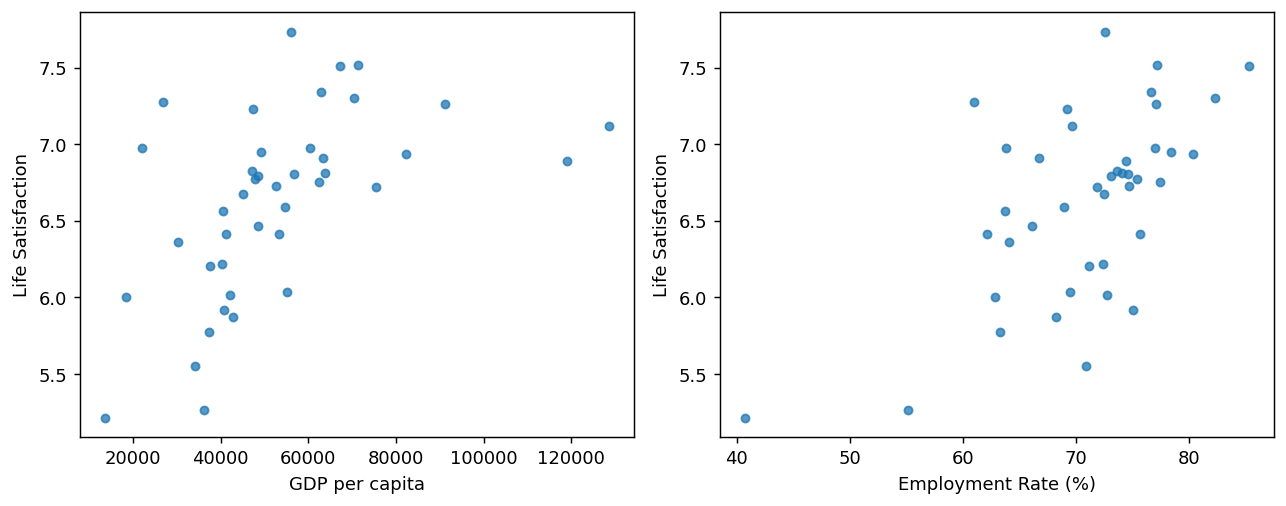

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
train.plot.scatter(x=FEATURES[0], y=TARGET, ax=axes[0], alpha=0.75)
train.plot.scatter(x=FEATURES[1], y=TARGET, ax=axes[1], alpha=0.75)
fig.tight_layout()
plt.show()

## 3. 单特征 k-NN：理解最近邻

首先只使用一个特征，并设置 `k=1`。预测韩国时，从其他国家中寻找该特征最接近的国家，再用该国的生活满意度作为预测值。

这个步骤对应原第一课的核心思想：**距离近的样本可能具有相似目标值**。

In [3]:
validation_country = "South Korea"
rows = []

for feature in FEATURES:
    candidates = X.drop(index=validation_country)
    distances = (
        candidates[feature] - X.loc[validation_country, feature]
    ).abs().sort_values()
    neighbor = distances.index[0]
    prediction = float(y.loc[neighbor])
    actual = float(y.loc[validation_country])
    rows.append({
        "特征": feature,
        "最近邻国家": neighbor,
        "距离": float(distances.iloc[0]),
        "预测值": prediction,
        "实际值": actual,
        "绝对误差": abs(prediction - actual),
    })

one_feature_result = pd.DataFrame(rows).set_index("特征").round(4)
one_feature_result

,最近邻国家,距离,预测值,实际值,绝对误差
特征,,,,,
GDP per capita,France,271.5900,6.593,6.038,0.555
Employment Rate (%),Luxembourg,0.1313,7.122,6.038,1.084


## 4. 多特征距离与标准化

直接计算二维欧氏距离会产生尺度问题：人均 GDP 的数值通常是数万，而就业率约为 0—100，因此未经处理时 GDP 几乎完全支配距离。

解决方法是在每个训练折中分别计算均值和标准差，再将特征变换为均值约为 0、标准差约为 1 的尺度。

In [4]:
raw_distance = np.linalg.norm(X.loc["South Korea"] - X.loc["Italy"])

X_mean = X.mean()
X_std = X.std()
X_scaled = (X - X_mean) / X_std
scaled_distance = np.linalg.norm(
    X_scaled.loc["South Korea"] - X_scaled.loc["Italy"]
)

print(f"标准化前的韩国—意大利距离：{raw_distance:.2f}")
print(f"标准化后的韩国—意大利距离：{scaled_distance:.4f}")

标准化前的韩国—意大利距离：1805.95
标准化后的韩国—意大利距离：0.9373


## 5. 从零实现 k-NN 回归

下面的函数接收已经标准化的训练特征、目标值和一个查询样本：

1. 计算查询样本到所有训练样本的欧氏距离；
2. 找到距离最小的 `k` 个位置；
3. 返回这些近邻目标值的平均数。

In [5]:
def fit_standardizer(frame):
    # 只使用当前训练集估计标准化参数。
    return frame.mean(), frame.std()


def standardize(frame, mean, std):
    # 使用训练集参数变换训练、验证或测试数据。
    return (frame - mean) / std


def knn_predict(X_train_scaled, y_train, x_query_scaled, k):
    # 返回预测值、近邻位置以及所有训练样本的距离。
    distances = np.linalg.norm(
        X_train_scaled.to_numpy(dtype=float)
        - x_query_scaled.to_numpy(dtype=float),
        axis=1,
    )
    neighbor_positions = np.argsort(distances)[:k]
    prediction = float(y_train.iloc[neighbor_positions].mean())
    return prediction, neighbor_positions, distances

## 6. 留一交叉验证选择 k

数据量较小，因此依次把每个国家作为验证样本，其余国家作为训练集。每次都重新计算标准化参数，避免验证数据参与训练。

对每个 `k` 汇总所有国家的绝对误差，平均误差最低的 `k` 被选为最终超参数。

In [6]:
k_values = list(range(1, len(X)))
error_rows = {}

for validation_country in X.index:
    X_train = X.drop(index=validation_country)
    y_train = y.drop(index=validation_country)
    x_validation = X.loc[validation_country]

    # 关键：每个验证折只使用该折训练集计算 mean/std。
    mean, std = fit_standardizer(X_train)
    X_train_scaled = standardize(X_train, mean, std)
    x_validation_scaled = standardize(x_validation, mean, std)

    errors = []
    for k in k_values:
        prediction, _, _ = knn_predict(
            X_train_scaled, y_train, x_validation_scaled, k
        )
        errors.append(abs(prediction - float(y.loc[validation_country])))
    error_rows[validation_country] = errors

error_table = pd.DataFrame(error_rows, index=k_values).T
mean_errors = error_table.mean(axis=0)
best_k = int(mean_errors.idxmin())

print(f"最优 k：{best_k}")
print(f"对应的留一交叉验证 MAE：{mean_errors.loc[best_k]:.4f}")

最优 k：14
对应的留一交叉验证 MAE：0.3659


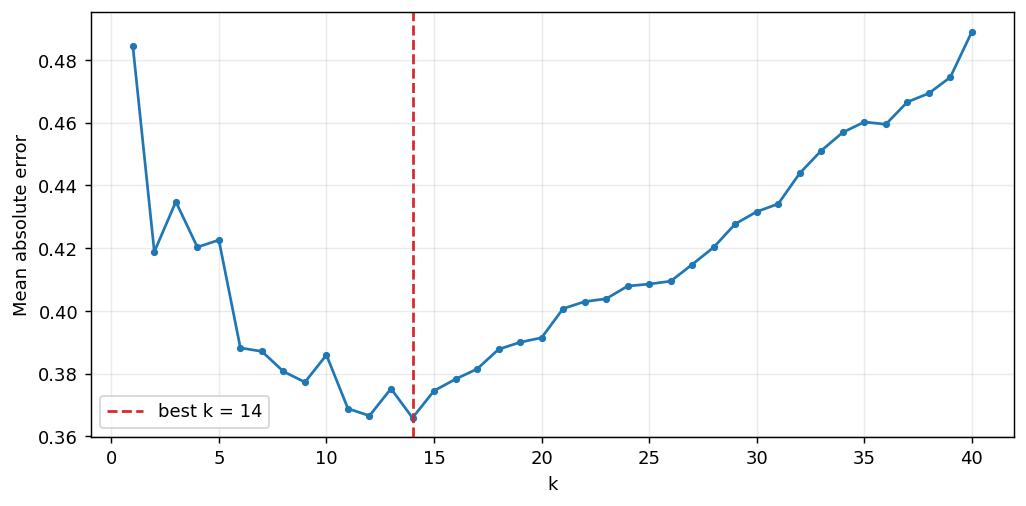

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mean_errors.index, mean_errors.values, marker="o", markersize=3)
ax.axvline(best_k, color="tab:red", linestyle="--", label=f"best k = {best_k}")
ax.set_xlabel("k")
ax.set_ylabel("Mean absolute error")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 7. 与简单基线模型比较

模型必须优于简单规则才有实际意义。这里比较：

- **训练集均值基线**：所有样本都预测为当前训练集的平均生活满意度；
- **线性回归基线**：用 NumPy 最小二乘法拟合两个标准化特征；
- **k-NN**：使用交叉验证选出的 `k`。

线性回归的平均验证误差略低于 k-NN，说明当前数据总体关系可能更接近线性趋势。诚实展示这一结果比只报告 k-NN 的最好成绩更有分析价值。

In [8]:
mean_baseline_errors = []
linear_errors = []

for validation_country in X.index:
    X_train = X.drop(index=validation_country)
    y_train = y.drop(index=validation_country)
    x_validation = X.loc[validation_country]
    actual = float(y.loc[validation_country])

    mean_baseline_errors.append(abs(float(y_train.mean()) - actual))

    mean, std = fit_standardizer(X_train)
    X_train_scaled = standardize(X_train, mean, std)
    x_validation_scaled = standardize(x_validation, mean, std)
    design = np.column_stack([
        np.ones(len(X_train_scaled)),
        X_train_scaled.to_numpy(dtype=float),
    ])
    coefficients = np.linalg.lstsq(
        design, y_train.to_numpy(dtype=float), rcond=None
    )[0]
    linear_prediction = float(
        np.r_[1.0, x_validation_scaled.to_numpy(dtype=float)] @ coefficients
    )
    linear_errors.append(abs(linear_prediction - actual))

comparison = pd.DataFrame({
    "模型": ["训练集均值基线", "线性回归基线", f"k-NN（k={best_k}）"],
    "留一交叉验证 MAE": [
        np.mean(mean_baseline_errors),
        np.mean(linear_errors),
        mean_errors.loc[best_k],
    ],
}).set_index("模型").sort_values("留一交叉验证 MAE").round(4)
comparison

,留一交叉验证 MAE
模型,
线性回归基线,0.3498
k-NN（k=14）,0.3659
训练集均值基线,0.4890


## 8. 最终预测：日本

只有完成超参数选择后，才首次使用日本的特征进行最终预测。标准化参数由全部 41 个训练国家计算，日本使用同一组参数进行变换。

In [9]:
final_mean, final_std = fit_standardizer(X)
X_final_scaled = standardize(X, final_mean, final_std)
japan_scaled = standardize(
    test.loc["Japan", FEATURES].astype(float), final_mean, final_std
)

japan_prediction, neighbor_positions, distances = knn_predict(
    X_final_scaled, y, japan_scaled, best_k
)
japan_actual = float(test.loc["Japan", TARGET])

print(f"使用的 k：{best_k}")
print(f"日本生活满意度预测值：{japan_prediction:.3f}")
print(f"日本生活满意度实际值：{japan_actual:.3f}")
print(f"绝对误差：{abs(japan_prediction - japan_actual):.3f}")

使用的 k：14
日本生活满意度预测值：6.656
日本生活满意度实际值：6.147
绝对误差：0.509


In [10]:
neighbors = pd.DataFrame({
    "距离": distances[neighbor_positions],
    "生活满意度": y.iloc[neighbor_positions].to_numpy(),
}, index=y.index[neighbor_positions]).round(4)
neighbors.index.name = "国家"
neighbors

,距离,生活满意度
国家,,
New Zealand,0.1869,6.952
Czechia,0.5168,6.775
Estonia,0.5183,6.417
Hungary,0.5998,5.915
United Kingdom,0.6599,6.728
Australia,0.6859,6.974
Lithuania,0.7409,6.829
Germany,0.7568,6.753
Canada,0.7606,6.803


## 9. 结论与局限

### 主要结果

- 单特征最近邻容易受特征选择影响；GDP 的单特征表现优于就业率。
- 多特征距离必须先处理尺度差异。
- 留一交叉验证选择的最优参数为 **`k=14`**，平均 MAE 为 **0.3659**。
- 日本的预测生活满意度为 **6.656**，实际值为 **6.147**，绝对误差为 **0.509**。
- 线性回归的留一验证 MAE（**0.3498**）略优于 k-NN，说明模型选择不能只依赖单个测试样本。

### 局限

1. 2024 年只有 42 个国家，样本量很小。
2. 最终测试集只有日本一个样本，无法稳定估计泛化误差。
3. GDP 和就业率不能完整解释生活满意度，教育、健康、社会支持等变量可能同样重要。
4. 当前分析展示相关性预测，不代表因果关系。
5. 数据来源、更新流程和许可证需要进一步补充后才能安全再发布。

### 可继续改进

- 使用多年度面板数据并设置多个测试国家；
- 加入更多社会经济特征；
- 比较正则化线性模型、树模型等方法；
- 对预测不确定性和特征敏感性进行分析。